# Fractured Cast Cleanup

Some Ruikar **fractured** knee CTs were scanned inside a **cylindrical cast/holder**. The cast is dense (~200 HU) and *fused* to the limb at the soft-tissue level, so it cannot be removed automatically by connected-component body isolation (see `predrr_preprocessing.ipynb`). The cast is therefore removed **manually in 3D Slicer**, producing `data/external/manual_cast_removal_fractured/<case>_cast_removal.nrrd`.

Manual segmentation leaves **small residual specks** behind — CT table / mattress / B80s streak bits, mostly at the posterior (bottom) edge, disconnected from the limb by an air gap. This notebook removes those **automatically and safely**.

**Method (confirmed with the user):** at a bone threshold (HU > 200) we label connected components, keep the **main bone**, keep anything **within 15 mm** of it, keep any **dense sizeable fragment** regardless of distance (rescue), and **drop everything else** (the table/streak specks). Because nothing adjacent to bone is ever removed, displaced fracture fragments are safe.

**Output:** `data/interim/fractured_cast_cleaned/<Case>_clean.nii.gz` (geometry preserved), which then replaces the raw fractured input for that case in `predrr_preprocessing.ipynb`.

In [1]:
import re
from pathlib import Path
import numpy as np
import SimpleITK as sitk
from scipy import ndimage
import matplotlib.pyplot as plt

# ---- resolve project root (folder that contains data/interim) ----
def find_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "data" / "interim").exists():
            return cand
    raise FileNotFoundError("could not find project root (expected data/interim)")

ROOT    = find_root(Path.cwd())
IN_DIR  = ROOT / "data" / "external" / "manual_cast_removal_fractured"
OUT_DIR = ROOT / "data" / "interim" / "fractured_cast_cleaned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- cleanup parameters (validated on Case3; applied to Case16) ----
BONE_HU    = 200    # threshold separating bone/cast/specks from soft tissue
KEEP_MM    = 15.0   # keep any component within this distance of the main bone
RESCUE_HU  = 800    # ... or any component at least this dense ...
RESCUE_VOX = 500    # ... and at least this large (rescues a genuinely displaced fragment)
REPORT_MIN_VOX = 50 # only list dropped components above this size in the report

print("ROOT  :", ROOT)
print("input :", IN_DIR)
print("output:", OUT_DIR)
files = sorted(IN_DIR.glob("*.nrrd"))
print("found %d manual-cast-removal file(s):" % len(files), [f.name for f in files])

ROOT  : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject
input : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\external\manual_cast_removal_fractured
output: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\fractured_cast_cleaned
found 2 manual-cast-removal file(s): ['case_16_cast_removal.nrrd', 'case_3_cast_removal.nrrd']


## Cleanup function

`clean_specks` works in HU on the array in `(z, y, x)` order, with the real voxel spacing so the
15 mm gate is physical (these scans are anisotropic: ~0.39 mm in-plane, 3.0 mm slices). It returns
the cleaned array plus a **report** of every dropped component (size, distance to bone, peak HU) so
the removal is auditable, never silent.

In [2]:
def clean_specks(arr_hu, spacing_zyx, bone_hu=BONE_HU, keep_mm=KEEP_MM,
                 rescue_hu=RESCUE_HU, rescue_vox=RESCUE_VOX):
    """Remove disconnected table/mattress/streak specks left after manual cast removal.

    Keeps the main bone component, anything within `keep_mm` of it, and any dense sizeable
    fragment (rescue) regardless of distance; drops everything else. Nothing adjacent to bone is
    ever removed, so fracture fragments are safe. Returns (cleaned_arr, dropped_report)."""
    occ = arr_hu > bone_hu
    lbl, n = ndimage.label(occ)
    if n == 0:
        return arr_hu, []
    sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
    main = int(np.argmax(sizes)) + 1
    # distance (mm) of every voxel to the MAIN bone component
    edt = ndimage.distance_transform_edt(lbl != main, sampling=spacing_zyx)
    drop = np.zeros_like(occ)
    report = []
    for i in range(1, n + 1):
        if i == main:
            continue
        comp = lbl == i
        d  = float(edt[comp].min()); sz = int(sizes[i - 1]); hu = float(arr_hu[comp].max())
        keep = (d <= keep_mm) or (hu >= rescue_hu and sz >= rescue_vox)
        if not keep:
            drop |= comp
            if sz >= REPORT_MIN_VOX:
                report.append(dict(size=sz, dist_mm=round(d, 1), hu_max=round(hu)))
    out = arr_hu.copy()
    out[drop] = float(arr_hu.min())   # set removed specks to background (air)
    return out, sorted(report, key=lambda r: -r["size"])


def case_id_from(path):
    """`case_3_cast_removal.nrrd` -> `Case3` (filenames may be mislabelled; trust the number)."""
    m = re.search(r"case[_\- ]*(\d+)", path.stem, re.I)
    return ("Case%s" % m.group(1)) if m else path.stem

print("clean_specks() and case_id_from() defined.")

clean_specks() and case_id_from() defined.


## Process each file (clean → QA render → save)

For every `*.nrrd`: clean it, print the dropped-component report, show **before/after** MIPs (axial /
coronal / sagittal) so you can confirm the bone is untouched and only specks were removed, then save
`<Case>_clean.nii.gz` with the original geometry.


=== Case16 (case_16_cast_removal.nrrd) ===
  spacing(z,y,x) mm: (np.float64(0.7), np.float64(0.428), np.float64(0.428)) | shape: (337, 512, 512)
  removed 3522 voxels (0.34% of bone>200 HU) across 8 reported component(s):
     size=1419   dist= 61.7 mm  HUmax=379
     size=375    dist= 17.3 mm  HUmax=297
     size=131    dist= 33.9 mm  HUmax=334
     size=113    dist=129.3 mm  HUmax=858
     size=103    dist= 58.3 mm  HUmax=284
     size=91     dist= 34.9 mm  HUmax=278
     size=79     dist= 34.9 mm  HUmax=255
     size=74     dist= 25.1 mm  HUmax=242


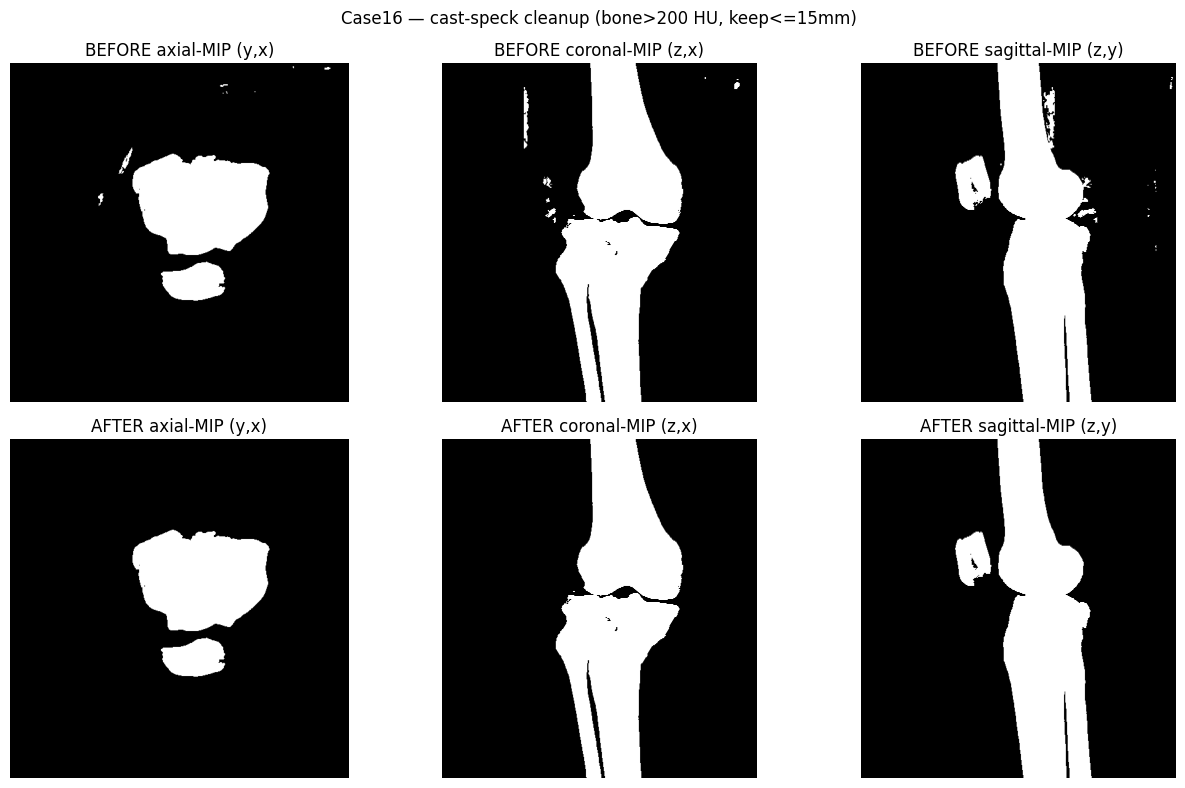

  saved -> data\interim\fractured_cast_cleaned\Case16_clean.nii.gz

=== Case3 (case_3_cast_removal.nrrd) ===
  spacing(z,y,x) mm: (np.float64(3.0), np.float64(0.387), np.float64(0.387)) | shape: (82, 512, 512)
  removed 13445 voxels (3.50% of bone>200 HU) across 14 reported component(s):
     size=1277   dist=104.4 mm  HUmax=461
     size=273    dist= 30.7 mm  HUmax=317
     size=176    dist= 23.0 mm  HUmax=315
     size=157    dist= 24.0 mm  HUmax=331
     size=122    dist= 54.0 mm  HUmax=794
     size=115    dist= 25.7 mm  HUmax=298
     size=99     dist= 24.7 mm  HUmax=355
     size=91     dist= 42.0 mm  HUmax=322
     size=87     dist= 27.1 mm  HUmax=298
     size=85     dist= 47.7 mm  HUmax=312
     size=79     dist= 58.5 mm  HUmax=307
     size=71     dist= 29.7 mm  HUmax=321
     size=57     dist= 17.8 mm  HUmax=303
     size=55     dist= 43.3 mm  HUmax=303


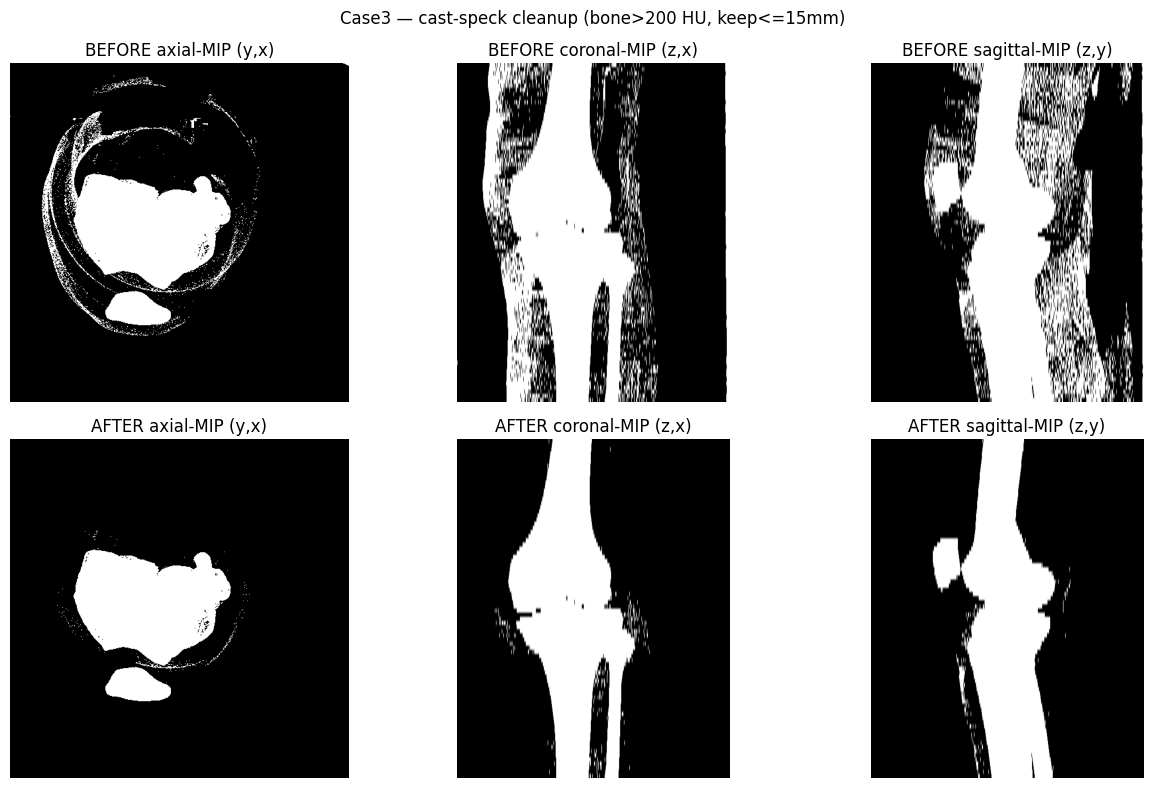

  saved -> data\interim\fractured_cast_cleaned\Case3_clean.nii.gz

Done. Cleaned volumes in: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\fractured_cast_cleaned


In [3]:
for f in files:
    cid = case_id_from(f)
    img = sitk.ReadImage(str(f))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)          # (z, y, x), HU
    spacing_zyx = np.array(img.GetSpacing()[::-1], dtype=float)   # (z, y, x) mm

    cleaned, report = clean_specks(arr, spacing_zyx)
    n_drop_vox = int(((arr > BONE_HU) & ~(cleaned > BONE_HU)).sum())
    base = int((arr > BONE_HU).sum())
    print("\n=== %s (%s) ===" % (cid, f.name))
    print("  spacing(z,y,x) mm:", tuple(round(s, 3) for s in spacing_zyx),
          "| shape:", arr.shape)
    print("  removed %d voxels (%.2f%% of bone>%d HU) across %d reported component(s):"
          % (n_drop_vox, 100 * n_drop_vox / max(base, 1), BONE_HU, len(report)))
    for r in report:
        print("     size=%-6d dist=%5.1f mm  HUmax=%d" % (r["size"], r["dist_mm"], r["hu_max"]))

    # QA: before/after MIPs (anisotropic aspect so proportions are physical)
    fig, ax = plt.subplots(2, 3, figsize=(13, 8))
    az, ay, ax_ = spacing_zyx
    for row, (vol, tag) in enumerate([(arr, "BEFORE"), (cleaned, "AFTER")]):
        o = vol > BONE_HU
        ax[row, 0].imshow(o.max(0), cmap="gray", origin="lower")
        ax[row, 0].set_title("%s axial-MIP (y,x)" % tag)
        ax[row, 1].imshow(o.max(1), cmap="gray", origin="lower", aspect=az / ax_)
        ax[row, 1].set_title("%s coronal-MIP (z,x)" % tag)
        ax[row, 2].imshow(o.max(2), cmap="gray", origin="lower", aspect=az / ay)
        ax[row, 2].set_title("%s sagittal-MIP (z,y)" % tag)
    for a in ax.ravel():
        a.axis("off")
    plt.suptitle("%s — cast-speck cleanup (bone>%d HU, keep<=%.0fmm)" % (cid, BONE_HU, KEEP_MM))
    plt.tight_layout(); plt.show()

    # save cleaned volume with original geometry (spacing/origin/direction preserved)
    out_img = sitk.GetImageFromArray(cleaned)
    out_img.CopyInformation(img)
    out_path = OUT_DIR / ("%s_clean.nii.gz" % cid)
    sitk.WriteImage(out_img, str(out_path))
    print("  saved ->", out_path.relative_to(ROOT))

print("\nDone. Cleaned volumes in:", OUT_DIR)

## Next steps

1. **Review** each before/after render above: the AFTER MIPs must show the same bone (femur, tibia,
   fibula, patella, fracture fragments) as BEFORE, with only the table/streak specks gone. If a real
   fragment was dropped, raise `KEEP_MM` or lower `RESCUE_HU`/`RESCUE_VOX` and re-run.
2. **Feed into `predrr_preprocessing.ipynb`**: point the Case3 / Case16 entries at the matching
   `data/interim/fractured_cast_cleaned/<Case>_clean.nii.gz` (source format `nifti`) instead of the
   raw cast-containing DICOM (via the `CAST_CLEANED` override), then regenerate predrr → DRRs →
   occupancy cache as usual. (Case5 / Case11 are CT-table cases separated by an air gap — they are
   removed automatically by the body-envelope mask and need no manual cast cleanup.)
3. The automatic **body-envelope mask** in `predrr_preprocessing.ipynb` still runs on these cleaned
   volumes (harmless: the table is already gone, so it is essentially a no-op for them).